In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [7]:
# Define file paths
BASE_DIR = Path().resolve().parent
raw_path = BASE_DIR / "data" / "raw" / "bengaluru_house_prices.csv"
processed_path = BASE_DIR / "data" / "processed" / "train_data.csv"
print(raw_path)
print(processed_path)

C:\Users\munja\machine_learning_application\data\raw\bengaluru_house_prices.csv
C:\Users\munja\machine_learning_application\data\processed\train_data.csv


In [8]:
df = pd.read_csv(processed_path)
df.shape

(8658, 9)

In [9]:
# check data types for all the features
print(df.dtypes)

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


In [10]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,NaN,1050,2.0,1.0,64.8
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,PuoodSk,1690,3.0,1.0,125.0
2,Built-up Area,Ready To Move,Hebbal,2 BHK,NaN,1100,2.0,1.0,60.0
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,NaN,1200,4.0,2.0,110.0
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,LGifeew,2429,3.0,1.0,210.0


In [11]:
# Check for missing values in the 'society' column
df['society'].isnull().sum()

np.int64(3616)

In [12]:
# Check for missing values in the 'society' column with percentage
missing_society = df['society'].isnull().sum()
total_rows = df.shape[0]
missing_percentage = (missing_society / total_rows) * 100
missing_percentage

np.float64(41.76484176484176)

In [13]:
# to tackle missing values we can impute them with mean, median or mode 
# but in this case dropping the column is a better option as it has more than 40% missing values

df.drop(columns=['society'], inplace=True)

In [14]:
# Check the shape of the dataframe after dropping the 'society' column
df.shape

(8658, 8)

In [15]:
# now check for null values in the dataframe
df.isnull().sum()

area_type         0
availability      0
location          1
size             14
total_sqft        0
bath             47
balcony         401
price             0
dtype: int64

In [16]:
#  Location has 1 missing value, we can drop that row as it is only 1 row and it won't affect our model much
df.dropna(subset=['location'], inplace=True)

In [17]:
# For bath it has 47 missing values, we can impute them with median as it is a numerical column
# the reason for using median is that it won't be affected by outliers, mean can be affected by outliers and it can give us a wrong imputation value
df['bath'].fillna(df['bath'].median(), inplace=True)

C:\Users\munja\AppData\Local\Temp\ipykernel_3904\380108658.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(df['bath'].median(), inplace=True)


In [18]:
# For balcony it has 401 missing values, we can impute them with mode as it is a categorical column
# the reason for using mode is that it is a categorical column and it can give us the most frequent value in that column
df['balcony'].fillna(df['balcony'].mode()[0], inplace=True)

C:\Users\munja\AppData\Local\Temp\ipykernel_3904\3035492003.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(df['balcony'].mode()[0], inplace=True)


In [19]:
#  Handling missing values in size column, as there are only 14 missing values, we can drop those rows as it won't affect our model much
df.dropna(subset=['size'], inplace=True)

In [20]:
# checking null values in the dataframe after handling missing values
df.isnull().sum(), df.shape

(area_type       0
 availability    0
 location        0
 size            0
 total_sqft      0
 bath            0
 balcony         0
 price           0
 dtype: int64,
 (8643, 8))

In [21]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,1050,2.0,1.0,64.8
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,1690,3.0,1.0,125.0
2,Built-up Area,Ready To Move,Hebbal,2 BHK,1100,2.0,1.0,60.0
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,1200,4.0,2.0,110.0
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,2429,3.0,1.0,210.0


In [22]:
# Feature Engineering - Converting sqft column to numerical values

def convert_sqft_to_num(x):
    try:
        if '-' in x:
            tokens = x.split('-')
            if len(tokens) == 2:
                return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

In [23]:
df['new_total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

In [24]:
df['new_total_sqft'].value_counts()

new_total_sqft
1200.0    537
1100.0    149
2400.0    137
1500.0    126
600.0     119
         ... 
704.0       1
959.0       1
4334.0      1
885.0       1
910.2       1
Name: count, Length: 1669, dtype: int64

In [25]:
df.isnull().sum()

area_type          0
availability       0
location           0
size               0
total_sqft         0
bath               0
balcony            0
price              0
new_total_sqft    31
dtype: int64

In [26]:
# Dropping the original 'total_sqft' column as we have created a new column 'new_total_sqft' with numerical values
# Also dropping null values in 'new_total_sqft' column as it is a small number of rows and it won't affect our model much
df.drop(columns=['total_sqft'], inplace=True)
df.dropna(subset=['new_total_sqft'], inplace=True)

In [27]:
df.isnull().sum()

area_type         0
availability      0
location          0
size              0
bath              0
balcony           0
price             0
new_total_sqft    0
dtype: int64

In [28]:
df.shape

(8612, 8)

In [29]:
df.head()

,area_type,availability,location,size,bath,balcony,price,new_total_sqft
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,2.0,1.0,64.8,1050.0
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,3.0,1.0,125.0,1690.0
2,Built-up Area,Ready To Move,Hebbal,2 BHK,2.0,1.0,60.0,1100.0
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,4.0,2.0,110.0,1200.0
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,3.0,1.0,210.0,2429.0


In [30]:
# Feature Engineering - Extracting number of bedrooms from size column

df['new_size'] = df['size'].str.extract('(\d+)').astype(float)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\munja\AppData\Local\Temp\ipykernel_3904\1658550702.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['new_size'] = df['size'].str.extract('(\d+)').astype(float)


In [31]:
df['new_size'].value_counts()

new_size
2.0     3554
3.0     3161
4.0      917
1.0      439
5.0      220
6.0      148
7.0       67
8.0       56
9.0       33
10.0       9
11.0       2
43.0       1
19.0       1
27.0       1
16.0       1
13.0       1
12.0       1
Name: count, dtype: int64

In [32]:
# drop the original 'size' column as we have created a new column 'new_size' with numerical values
df.drop(columns=['size'], inplace=True)

In [33]:
df.head()

,area_type,availability,location,bath,balcony,price,new_total_sqft,new_size
0,Built-up Area,Ready To Move,Banjara Layout,2.0,1.0,64.8,1050.0,2.0
1,Super built-up Area,Ready To Move,Rajiv Nagar,3.0,1.0,125.0,1690.0,3.0
2,Built-up Area,Ready To Move,Hebbal,2.0,1.0,60.0,1100.0,2.0
3,Plot Area,Ready To Move,Munnekollal,4.0,2.0,110.0,1200.0,6.0
4,Built-up Area,18-Apr,Choodasandra,3.0,1.0,210.0,2429.0,4.0


In [34]:
# Outlier Detection and Removal - new_size column

df['new_size'].describe()

count    8612.000000
mean        2.803298
std         1.324961
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max        43.000000
Name: new_size, dtype: float64

In [35]:
df['new_size'].value_counts()

new_size
2.0     3554
3.0     3161
4.0      917
1.0      439
5.0      220
6.0      148
7.0       67
8.0       56
9.0       33
10.0       9
11.0       2
43.0       1
19.0       1
27.0       1
16.0       1
13.0       1
12.0       1
Name: count, dtype: int64

In [36]:
df[df['new_size'] > 9].shape

(17, 8)

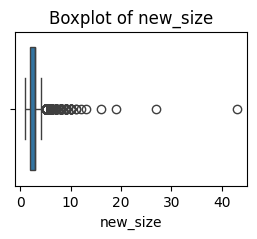

In [37]:
plt.figure(figsize=(3, 2))
sns.boxplot(x=df['new_size'])
plt.title('Boxplot of new_size')
plt.show()

In [38]:
df.shape

(8612, 8)

In [39]:
# Checking how many outliers are there in new_size column
# we cannot use IQR methods as data is discrete that is 1,2,3,4 etc.
# IQR works best on continous data, we can use logic here that any value greater 
# than 9 is an outlier as it is very rare to have more than 9 bedrooms in a house in Bengaluru

# now lets remove outliers from new_size column
df = df[df['new_size'] <= 9]
df.shape

(8595, 8)

In [40]:
df['new_size'].describe()

count    8595.000000
mean        2.780686
std         1.166078
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         9.000000
Name: new_size, dtype: float64

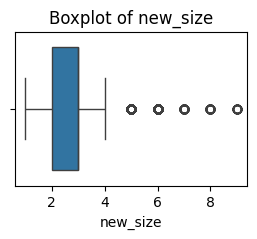

In [41]:
# Although box plot is still showing some outliers but BHK values are now within realistic range (1–9)
# Boxplot still shows statistical outliers due to IQR method. However, these values (5–9 BHK) are valid in real-world scenarios

plt.figure(figsize=(3, 2))
sns.boxplot(x=df['new_size'])
plt.title('Boxplot of new_size')
plt.show()

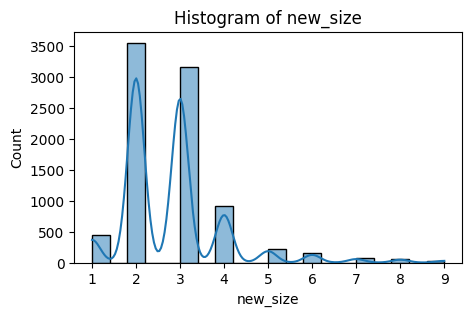

In [42]:
# lets check through histogram
plt.figure(figsize=(5, 3))
sns.histplot(df['new_size'], bins=20, kde=True)
plt.title('Histogram of new_size')
plt.show()

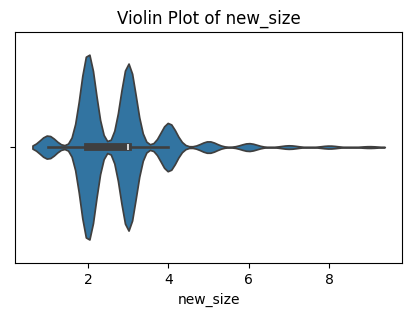

In [43]:
plt.figure(figsize=(5, 3))
sns.violinplot(x=df['new_size'])
plt.title('Violin Plot of new_size')
plt.show()

In [44]:
df.head()

,area_type,availability,location,bath,balcony,price,new_total_sqft,new_size
0,Built-up Area,Ready To Move,Banjara Layout,2.0,1.0,64.8,1050.0,2.0
1,Super built-up Area,Ready To Move,Rajiv Nagar,3.0,1.0,125.0,1690.0,3.0
2,Built-up Area,Ready To Move,Hebbal,2.0,1.0,60.0,1100.0,2.0
3,Plot Area,Ready To Move,Munnekollal,4.0,2.0,110.0,1200.0,6.0
4,Built-up Area,18-Apr,Choodasandra,3.0,1.0,210.0,2429.0,4.0


In [45]:
# Outlier Detection and Removal - new_total_sqft column
# new_total_sqft is continuous variable, we can use IQR method to detect outliers

df['new_total_sqft'].describe()

count     8595.000000
mean      1547.531858
std       1201.589163
min          1.000000
25%       1100.000000
50%       1275.000000
75%       1675.000000
max      52272.000000
Name: new_total_sqft, dtype: float64

In [46]:
df['new_total_sqft'].value_counts()

new_total_sqft
1200.00    531
1100.00    149
2400.00    136
1500.00    126
600.00     119
          ... 
673.00       1
1563.05      1
1637.00      1
582.50       1
2777.29      1
Name: count, Length: 1664, dtype: int64

In [47]:
df[df['new_total_sqft'] > 6000].shape,df[df['new_total_sqft'] > 3000].shape

((44, 8), (499, 8))

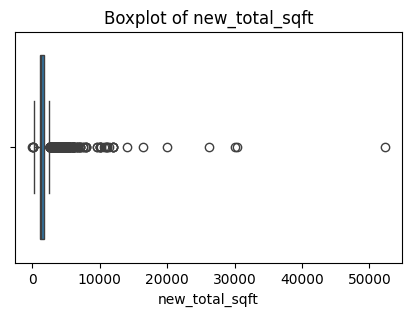

In [48]:
# create a boxplot for new_total_sqft column to visualize outliers
plt.figure(figsize=(5, 3))
sns.boxplot(x=df['new_total_sqft'])
plt.title('Boxplot of new_total_sqft')
plt.show()

In [49]:
# Intially tried removing on new_total_sqft using IQR method but instead we should
# try it on price_per_sqft column as it gives the clear picture of outliers
# because same sqft can have different price_per_sqft values because price can be different for same sqft and 
# it can help us to identify outliers more effectively than just looking at sqft values alone

# For example:
# House A: 1000 sqft, price 1 crore, price_per_sqft = 10000
# House B: 1000 sqft, price 50 lakhs, price_per_sqft = 5000
# so House A is more expensive than House B even though they have same sqft, 
# so we can use price_per_sqft to identify outliers more effectively than just looking at sqft values alone

In [50]:
df.shape

(8595, 8)

In [51]:
# Domain filtering on new_total_sqft column
# get sqft between 400 and 6000 sqft as it is a reasonable range for residential properties in Bengaluru
df = df[(df['new_total_sqft'] >= 400) & (df['new_total_sqft'] <= 6000)]
df.shape

(8534, 8)

In [52]:
# lets tackle the problem of global filtering vs local filtering by location
# as price_per_sqft can vary significantly across different locations in Bengaluru, 
# we should apply outlier detection and removal separately for each location rather 
# than applying a global filter on the entire dataset. This way we can identify outliers 
# that are specific to each location and retain valid data points that may be considered 
# outliers in a global context but are actually reasonable within their local context.
# for example, rs 6000/sqft normal in A location and rs 18000/sqft normal in B location, 
# now if we apply global filter on price_per_sqft rs 18000/sqft will be treated as the 
# outlier but it is actually a valid data point for that location, so we should apply outlier 
# detection and removal separately for each location to retain valid data points and remove true outliers effectively.

# so basically global filtering remove valid data points from high valued meaning high end properties disappears
# and model performs better on mid range propertieslocations and create a biased dataset and it hampers the model performance.
# model performs wrong for extreme values because model never knew those values during training
# what we are trying to do is find its normal range for each location then we are gonna train on that
# so that model performs better on extreme values as well For example:
# Property A: Mean:6000, Keep:5000-7000, Remove:20,000
# Property B: Mean:18000, Keep:15000-21000, Remove:4000
# that way each group keep its real distribution


# "Always ask this question does this feature behaves differently across groups?"
# If yes means: Apply outlier detection and removal separately for each group to retain valid data points and remove true outliers effectively.
# If no means: Apply outlier detection and removal on the entire dataset to identify and remove
# For example: here price per sqft behaves differently across different locations in Bengaluru, so we should apply outlier detection 
# and removal separately for each location to retain valid data points and remove true outliers effectively.

# For example: In finance dataset, income behaves differently across different job types, 
# so we should apply outlier detection and removal separately for each job type to retain valid data 
# points and remove true outliers effectively.


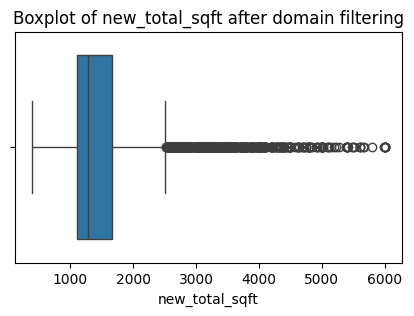

In [53]:
# box plot after domain filtering
plt.figure(figsize=(5, 3))
sns.boxplot(x=df['new_total_sqft'])
plt.title('Boxplot of new_total_sqft after domain filtering')
plt.show()

In [54]:
# calculate new column price_per_sqft using price and new_total_sqft columns
df['price_per_sqft'] = df['price']*100000 / df['new_total_sqft']
df.shape

(8534, 9)

In [55]:
df['price_per_sqft'].describe()

count     8534.000000
mean      6645.915041
std       4237.013441
min        500.000000
25%       4279.387166
50%       5448.496905
75%       7273.706897
max      76530.612245
Name: price_per_sqft, dtype: float64

In [56]:
print(df[df['price_per_sqft'] > 20000].shape)
print(df[df['price_per_sqft'] < 2500].shape)

(132, 9)
(43, 9)


In [57]:
df["price_per_sqft"].value_counts()

price_per_sqft
5000.000000     97
4000.000000     85
10000.000000    45
5500.000000     40
3000.000000     38
                ..
5834.355828      1
10350.000000     1
4500.723589      1
4211.469534      1
6792.452830      1
Name: count, Length: 5353, dtype: int64

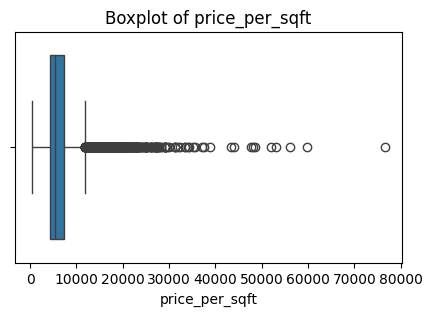

In [58]:
# box plot on price_per_sqft column to visualize outliers
plt.figure(figsize=(5, 3))
sns.boxplot(x=df['price_per_sqft'])
plt.title('Boxplot of price_per_sqft')
plt.show()

In [59]:
df.shape

(8534, 9)

In [60]:
# Location | price_per_sqft (using local filtering) because for 
# every location in bengaluru price_per_sqft behaves differently
# *******This is local/group based filtering*******
# now we are going to apply outlier detection and removal separately for each location to 
# retain valid data points and remove true outliers effectively

In [61]:
def remove_price_per_sqft_outliers(df):

    # create an empty dataframe to store the filtered data
    df_out = pd.DataFrame()  

    for location,sub_df in df.groupby('location'):
        # groupby role is to group similar location together 
        # example: Group A: whitefield | rs 10000 /sqft,  whitefield | rs 15000 /sqft
        # example: Group B: indiranagar | rs 9000 /sqft,  indiranagar | rs 19000 /sqft
        # location means one group or location at the time, subdf gets all the rows in the group/location
        print(location)

        # calulate mean and std of one location
        mean = sub_df['price_per_sqft'].mean()
        std = sub_df['price_per_sqft'].std()

        # filter values that are within one standard deviation of the mean for that location
        reduced_df = sub_df[(sub_df['price_per_sqft'] >= (mean - std)) & (sub_df['price_per_sqft'] <= (mean + std))]

        # append back to df_out dataframe
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out

In [62]:
df = remove_price_per_sqft_outliers(df)
df.shape

 Devarabeesana Halli
 Devarachikkanahalli
 Mysore Highway
 Rachenahalli
 Sector 1 HSR Layout
 Thanisandra
 Whitefield
 ittamadu
 south
12th cross srinivas nagar banshankari 3rd stage
1st Block BEL Layout
1st Block HBR Layout
1st Block HRBR Layout
1st Block Jayanagar
1st Block Koramangala
1st Phase JP Nagar
1st Stage Domlur
1st Stage Indira Nagar
1st Stage Radha Krishna Layout
2nd Block Bel Layout
2nd Block Hbr Layout
2nd Block Hrbr Layout
2nd Block Jayanagar
2nd Block Koramangala
2nd Phase JP Nagar
2nd Phase Judicial Layout
2nd Stage Arekere Mico Layout
2nd Stage Nagarbhavi
2nd phase jp nagar, jp nagar
3rd Block Banashankari
3rd Block HBR Layout
3rd Block Hrbr Layout
3rd Block Jayanagar
3rd Phase Iti Layout
3rd Phase JP Nagar
3rd Stage Raja Rajeshwari Nagar
4th Block HBR Layout
4th Block Jayanagar
4th Block Koramangala
4th Phase JP Nagar
4th T block Jayanagar
5th Block Hbr Layout
5th Block Jayanagar
5th Phase JP Nagar
6th Block Rajaji Nagar
6th Phase JP Nagar
6th block Koramangala
6th 

(6503, 9)

In [63]:
df.head()

,area_type,availability,location,bath,balcony,price,new_total_sqft,new_size,price_per_sqft
0,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,160.0,1670.0,3.0,9580.838323
1,Built-up Area,Ready To Move,Devarabeesana Halli,3.0,3.0,149.0,1750.0,3.0,8514.285714
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1672.0,3.0,8971.291866
3,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1750.0,3.0,8571.428571
4,Super built-up Area,Ready To Move,Devarachikkanahalli,2.0,2.0,65.0,1425.0,3.0,4561.403509


In [64]:
df.isnull().sum()

area_type         0
availability      0
location          0
bath              0
balcony           0
price             0
new_total_sqft    0
new_size          0
price_per_sqft    0
dtype: int64

In [65]:
# check duplicate rows in the dataframe
df.duplicated().sum()

np.int64(233)

In [66]:
# Using domain filtering lets remove values < 2500 and > 20000 from price_per_sqft column as 
# they are outliers and they can affect our model performance
# *******This is global based filtering*******
# df = df[(df['price_per_sqft'] >= 2500) & (df['price_per_sqft'] <= 20000)]
# df.shape

In [67]:
df['price_per_sqft'].describe()

count     6503.000000
mean      5970.159235
std       2904.101588
min       1666.666667
25%       4285.714286
50%       5285.171103
75%       6622.125085
max      37500.000000
Name: price_per_sqft, dtype: float64

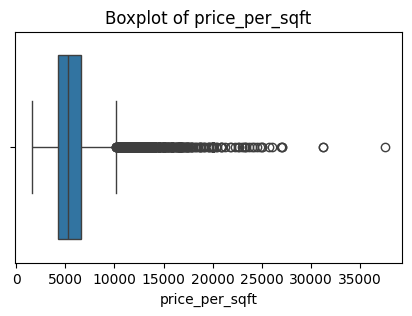

In [68]:
# box plot on price_per_sqft column after domain filtering
plt.figure(figsize=(5, 3))
sns.boxplot(x=df['price_per_sqft'])
plt.title('Boxplot of price_per_sqft')
plt.show()

In [69]:
df.head()

,area_type,availability,location,bath,balcony,price,new_total_sqft,new_size,price_per_sqft
0,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,160.0,1670.0,3.0,9580.838323
1,Built-up Area,Ready To Move,Devarabeesana Halli,3.0,3.0,149.0,1750.0,3.0,8514.285714
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1672.0,3.0,8971.291866
3,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1750.0,3.0,8571.428571
4,Super built-up Area,Ready To Move,Devarachikkanahalli,2.0,2.0,65.0,1425.0,3.0,4561.403509


In [70]:
# Price is in lakhs, value of price ranges from 10 lakhs to 12.50 crores, which is a 
# reasonable range for residential properties in Bengaluru
df['price'].describe()

count    6503.000000
mean       93.476342
std        86.332447
min        10.000000
25%        49.500000
50%        68.000000
75%       102.000000
max      1250.000000
Name: price, dtype: float64

In [71]:
df[df['price'] > 500][['price', 'new_total_sqft', 'price_per_sqft']]

,price,new_total_sqft,price_per_sqft
44,1100.0,4273.0,25743.037678
47,1150.0,4920.0,23373.983740
83,700.0,2240.0,31250.000000
225,650.0,2800.0,23214.285714
706,510.0,2400.0,21250.000000
1039,600.0,3569.0,16811.431774
1041,550.0,3633.0,15139.003578
1045,650.0,4460.0,14573.991031
1494,800.0,4170.0,19184.652278
1495,501.0,2880.0,17395.833333


In [72]:
df = df[df['price_per_sqft'] < 22000]

In [73]:
df['price'].describe()

count    6481.000000
mean       91.701072
std        78.766646
min        10.000000
25%        49.360000
50%        68.000000
75%       100.000000
max       995.000000
Name: price, dtype: float64

In [74]:
print(df[df['price'] > 500][['price', 'new_total_sqft', 'price_per_sqft']])

      price  new_total_sqft  price_per_sqft
706   510.0          2400.0    21250.000000
1039  600.0          3569.0    16811.431774
1041  550.0          3633.0    15139.003578
1045  650.0          4460.0    14573.991031
1494  800.0          4170.0    19184.652278
1495  501.0          2880.0    17395.833333
1498  662.0          3489.0    18973.918028
1499  995.0          5108.0    19479.248238
1500  763.0          3815.0    20000.000000
2063  750.0          4000.0    18750.000000
2921  525.0          2400.0    21875.000000
2923  700.0          4000.0    17500.000000
3099  700.0          5400.0    12962.962963
3109  700.0          4800.0    14583.333333
3663  716.0          3522.0    20329.358319
3691  625.0          6000.0    10416.666667
3706  775.0          5985.0    12949.039265
4376  510.0          3000.0    17000.000000
4544  600.0          4050.0    14814.814815
4575  550.0          2750.0    20000.000000
4580  700.0          4470.0    15659.955257
4588  600.0          4750.0    1

In [75]:
# lets add two new features sqft_per_bhk and bath_per_bhk to capture the relationship between sqft, bath and bhk
# through this model will understand: 
# "how spacious is each room?"
# "how many bathrooms are there per room?"

df['sqft_per_bhk'] = df['new_total_sqft'] / df['new_size']
df['bath_per_bhk'] = df['bath'] / df['new_size']

In [76]:
df.head()

,area_type,availability,location,bath,balcony,price,new_total_sqft,new_size,price_per_sqft,sqft_per_bhk,bath_per_bhk
0,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,160.0,1670.0,3.0,9580.838323,556.666667,1.000000
1,Built-up Area,Ready To Move,Devarabeesana Halli,3.0,3.0,149.0,1750.0,3.0,8514.285714,583.333333,1.000000
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1672.0,3.0,8971.291866,557.333333,1.000000
3,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1750.0,3.0,8571.428571,583.333333,1.000000
4,Super built-up Area,Ready To Move,Devarachikkanahalli,2.0,2.0,65.0,1425.0,3.0,4561.403509,475.000000,0.666667


In [77]:
# lets check both the new features
print(df[['sqft_per_bhk', 'bath_per_bhk']].describe())

       sqft_per_bhk  bath_per_bhk
count   6481.000000   6481.000000
mean     567.811548      0.965617
std      159.502032      0.173618
min       85.714286      0.400000
25%      487.500000      1.000000
50%      557.500000      1.000000
75%      625.000000      1.000000
max     2400.000000      2.000000


In [78]:
# filtering
df = df[(df['sqft_per_bhk'] >= 350) & (df['sqft_per_bhk'] <= 1000)]
df = df[(df['bath_per_bhk'] >= 0.5) & (df['bath_per_bhk'] <= 2)]
df = df[~((df['new_total_sqft'] > 2500) & (df['price'] < 60))]

In [79]:
print(df[['sqft_per_bhk', 'bath_per_bhk']].describe())

       sqft_per_bhk  bath_per_bhk
count   6059.000000   6059.000000
mean     569.705444      0.967337
std      111.707905      0.162123
min      350.000000      0.500000
25%      500.000000      1.000000
50%      562.500000      1.000000
75%      623.000000      1.000000
max     1000.000000      2.000000


In [80]:
df.shape

(6059, 11)

In [81]:
# Outlier removal on bath column
df['bath'].value_counts()

bath
2.0     3607
3.0     1565
1.0      350
4.0      343
5.0      114
6.0       56
7.0       17
8.0        4
9.0        2
14.0       1
Name: count, dtype: int64

In [82]:
df[df['bath'] > 7].shape

(7, 11)

In [83]:
df.shape

(6059, 11)

In [84]:
# Domain filtering filter values greater than 7 on bath column as it is a reasonable range 
# for residential properties in Bengaluru

df = df[df['bath'] <= 7]
df.shape

(6052, 11)

In [85]:
df.head()

,area_type,availability,location,bath,balcony,price,new_total_sqft,new_size,price_per_sqft,sqft_per_bhk,bath_per_bhk
0,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,160.0,1670.0,3.0,9580.838323,556.666667,1.000000
1,Built-up Area,Ready To Move,Devarabeesana Halli,3.0,3.0,149.0,1750.0,3.0,8514.285714,583.333333,1.000000
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1672.0,3.0,8971.291866,557.333333,1.000000
3,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1750.0,3.0,8571.428571,583.333333,1.000000
4,Super built-up Area,Ready To Move,Devarachikkanahalli,2.0,2.0,65.0,1425.0,3.0,4561.403509,475.000000,0.666667


In [86]:
df['balcony'].value_counts()

balcony
2.0    2633
1.0    2326
3.0     707
0.0     386
Name: count, dtype: int64

In [87]:
df['balcony'].describe()

count    6052.000000
mean        1.604924
std         0.774786
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: balcony, dtype: float64

In [88]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'bath',
 'balcony',
 'price',
 'new_total_sqft',
 'new_size',
 'price_per_sqft',
 'sqft_per_bhk',
 'bath_per_bhk']

In [89]:
# Now lets decide feature selection
# price_per_sqft we cannot use due to data leakage as it directly uses target variable price

df.drop(columns=['price_per_sqft'], inplace=True)
df.shape

(6052, 10)

In [90]:
df.head()

,area_type,availability,location,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk
0,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,160.0,1670.0,3.0,556.666667,1.000000
1,Built-up Area,Ready To Move,Devarabeesana Halli,3.0,3.0,149.0,1750.0,3.0,583.333333,1.000000
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1672.0,3.0,557.333333,1.000000
3,Super built-up Area,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1750.0,3.0,583.333333,1.000000
4,Super built-up Area,Ready To Move,Devarachikkanahalli,2.0,2.0,65.0,1425.0,3.0,475.000000,0.666667


In [91]:
# lets now handle the remaining features which are text based
# as area type is nominal data therefore we will use one hot encoding
df['area_type'].value_counts()

area_type
Super built-up  Area    4602
Built-up  Area          1095
Plot  Area               322
Carpet  Area              33
Name: count, dtype: int64

In [92]:
# one hot encoding for area_type column
area_type_dummies = pd.get_dummies(df['area_type'], drop_first=True)

In [93]:
# merger back one hot encoding columns back to the original dataframe
df = pd.concat([df, area_type_dummies], axis=1)

# drop the area_type column
df.drop(columns=['area_type'], inplace=True)

# view dataframe
df.head()

,availability,location,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk,Carpet Area,Plot Area,Super built-up Area
0,Ready To Move,Devarabeesana Halli,3.0,2.0,160.0,1670.0,3.0,556.666667,1.000000,False,False,True
1,Ready To Move,Devarabeesana Halli,3.0,3.0,149.0,1750.0,3.0,583.333333,1.000000,False,False,False
2,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1672.0,3.0,557.333333,1.000000,False,False,True
3,Ready To Move,Devarabeesana Halli,3.0,2.0,150.0,1750.0,3.0,583.333333,1.000000,False,False,True
4,Ready To Move,Devarachikkanahalli,2.0,2.0,65.0,1425.0,3.0,475.000000,0.666667,False,False,True


In [94]:
df.shape

(6052, 12)

In [95]:
df['availability'].value_counts().shape

(73,)

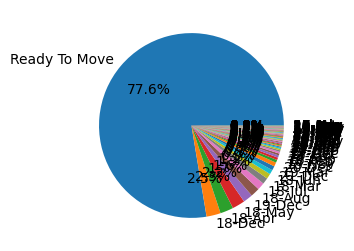

In [96]:
plt.figure(figsize=(5, 3))
plt.pie(df['availability'].value_counts(), labels=df['availability'].value_counts().index, autopct='%1.1f%%')
plt.show()

In [97]:
# lets convert availability column to binary values, if value is 'Ready To Move' then it will be 1 otherwise 0
# if ready house it means higher demand and it means maybe higher price else not ready

df['availability'] = df['availability'].apply(lambda x: 1 if x == 'Ready To Move' else 0)
df.head()

,availability,location,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk,Carpet Area,Plot Area,Super built-up Area
0,1,Devarabeesana Halli,3.0,2.0,160.0,1670.0,3.0,556.666667,1.000000,False,False,True
1,1,Devarabeesana Halli,3.0,3.0,149.0,1750.0,3.0,583.333333,1.000000,False,False,False
2,1,Devarabeesana Halli,3.0,2.0,150.0,1672.0,3.0,557.333333,1.000000,False,False,True
3,1,Devarabeesana Halli,3.0,2.0,150.0,1750.0,3.0,583.333333,1.000000,False,False,True
4,1,Devarachikkanahalli,2.0,2.0,65.0,1425.0,3.0,475.000000,0.666667,False,False,True


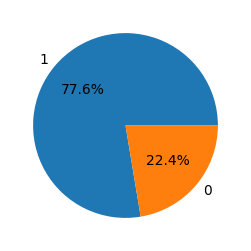

In [98]:
plt.figure(figsize=(5, 3))
plt.pie(df['availability'].value_counts(), labels=df['availability'].value_counts().index, autopct='%1.1f%%')
plt.show()

In [99]:
# now lets look at the location column
df['location'].value_counts()

location
Whitefield             294
Sarjapur  Road         209
Electronic City        173
Kanakpura Road         120
Uttarahalli            113
                      ... 
BTM 1st Stage            1
Andrahalli               1
Arishinakunte            1
9th Block Jayanagar      1
A Narayanapura           1
Name: count, Length: 627, dtype: int64

In [100]:
location_counts = df['location'].value_counts()
print(location_counts.shape)

print()
print(location_counts[location_counts <= 10].shape)
print(location_counts[location_counts > 10].shape)

print()
print(location_counts[location_counts <= 20].shape)
print(location_counts[location_counts > 20].shape)

print()
print(location_counts[location_counts <= 15].shape)
print(location_counts[location_counts > 15].shape)

print()
print(location_counts[location_counts <= 30].shape)
print(location_counts[location_counts > 30].shape)

(627,)

(488,)
(139,)

(556,)
(71,)

(529,)
(98,)

(588,)
(39,)


In [101]:
# lets take threshold as as 15 counts per location
threshold = 15
df['location'] = df['location'].apply(lambda x: x if location_counts[x] > threshold else 'Other')
df['location'].value_counts()

location
Other                     2055
Whitefield                 294
Sarjapur  Road             209
Electronic City            173
Kanakpura Road             120
                          ... 
Hebbal Kempapura            16
Kothannur                   16
Kengeri Satellite Town      16
Kalena Agrahara             16
Lakshminarayana Pura        16
Name: count, Length: 99, dtype: int64

In [102]:
# lets convert location column to one hot encoding
location_dummies = pd.get_dummies(df['location'], drop_first=True)
location_dummies

,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,Akshaya Nagar,Ambedkar Nagar,Attibele,Balagere,Banashankari,Bannerghatta Road,Basavangudi,...,Thigalarapalya,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6500,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6501,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [103]:
df.shape

(6052, 12)

In [104]:
# now lets concat location_dummies back to the original dataframe and drop the location column as well
df = pd.concat([df,location_dummies],axis=1)
df.drop(columns=['location'],inplace=True)
df.head()

,availability,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk,Carpet Area,Plot Area,...,Thigalarapalya,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,1,3.0,2.0,160.0,1670.0,3.0,556.666667,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,3.0,3.0,149.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3.0,2.0,150.0,1672.0,3.0,557.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,3.0,2.0,150.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,2.0,2.0,65.0,1425.0,3.0,475.000000,0.666667,False,False,...,False,False,False,False,False,False,False,False,False,False


In [105]:
df.shape

(6052, 109)

In [106]:
# columns to scale while training

cols_to_scale = [
                'new_total_sqft'
]

In [107]:
# check unique values in dataframe for various columns

cols_to_check_unique = [
    'availability',
    'bath',
    'balcony',
    'new_size',
    'bath_per_bhk'
]

# using loop check the unique values
for col in cols_to_check_unique:
    print(f"Unique values in column {col}: {df[col].unique()}")

Unique values in column availability: [1 0]
Unique values in column bath: [3. 2. 1. 5. 4. 7. 6.]
Unique values in column balcony: [2. 3. 1. 0.]
Unique values in column new_size: [3. 2. 1. 4. 5. 6. 7. 8.]
Unique values in column bath_per_bhk: [1.         0.66666667 0.75       1.25       2.         0.5
 0.8        0.83333333 1.5        1.16666667 1.33333333 1.66666667
 0.6        1.2        1.75       0.875      0.625      0.85714286
 1.4       ]


In [108]:
df['sqft_per_bhk'].nunique()

1230

In [109]:
df['new_total_sqft'].nunique()

1336

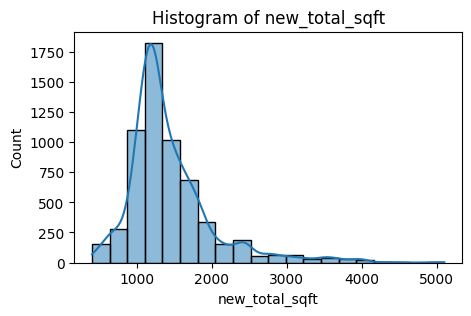

In [110]:
# the distribution of new_total_sqft column is right skewed, but as the per the domain logic 
# it is expected as there are more houses with smaller sqft than larger sqft in Bengaluru
# there is no need to do any transformation on new_total_sqft column as it is already in a 
# reasonable range and it is not affecting our model performance

plt.figure(figsize=(5, 3))
sns.histplot(df['new_total_sqft'], bins=20, kde=True)
plt.title('Histogram of new_total_sqft')
plt.show()

In [111]:
# check duplicate rows in the dataframe
df.duplicated().sum()

np.int64(316)

In [112]:
# Lets see which rows are duplicated
df[df.duplicated()]

,availability,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk,Carpet Area,Plot Area,...,Thigalarapalya,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
55,1,2.0,2.0,47.25,1350.0,3.0,450.000000,0.666667,False,False,...,False,False,False,False,False,False,False,False,False,False
57,1,2.0,2.0,47.25,1350.0,3.0,450.000000,0.666667,False,False,...,False,False,False,False,False,False,False,False,False,False
169,1,2.0,2.0,52.00,1300.0,3.0,433.333333,0.666667,False,False,...,False,False,False,False,False,False,False,False,False,False
171,1,2.0,1.0,39.33,1035.0,2.0,517.500000,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
177,1,2.0,1.0,42.00,1050.0,2.0,525.000000,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6369,1,3.0,2.0,95.00,1614.0,3.0,538.000000,1.000000,False,False,...,False,False,False,False,False,False,False,True,False,False
6443,1,2.0,2.0,46.17,1200.0,2.0,600.000000,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
6444,1,2.0,2.0,55.00,1100.0,2.0,550.000000,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
6484,1,3.0,3.0,140.00,1855.0,3.0,618.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,True


In [113]:
df.shape

(6052, 109)

In [114]:
# lets remove duplicate rows from the dataframe
df.drop_duplicates(inplace=True)
df.shape

(5736, 109)

In [115]:
# now lets check correlation between numerical features and target variable price
# new_total_sqft has a strong positive correlation with price, which is expected as larger houses tend to be more expensive
# bath and new_size also have positive correlation with price, which is expected as more bathrooms and sizes can increase the value of a house
# balcony and availability have very weak correlation with price, which is expected as they are not as important as other features in determining the price of a house

numerical_cols = ['new_total_sqft', 'new_size', 'bath', 'balcony', 'availability','sqft_per_bhk', 'bath_per_bhk']
correlation_matrix = df[numerical_cols + ['price']].corr()
correlation_matrix['price'].sort_values(ascending=False)

price             1.000000
new_total_sqft    0.794560
bath              0.638647
new_size          0.587441
sqft_per_bhk      0.512968
balcony           0.172591
bath_per_bhk      0.167488
availability      0.062105
Name: price, dtype: float64

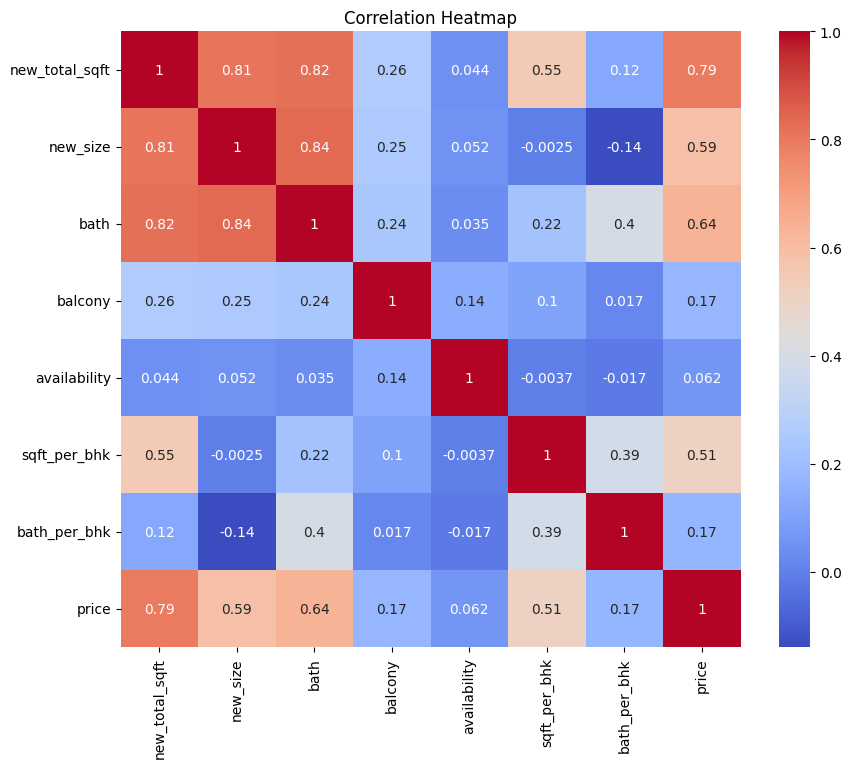

In [116]:
# lets check multicollinearity using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [117]:
# lets check using VIF to check multicollinearity between features

X = df[['new_total_sqft', 'new_size', 'bath', 'balcony', 'availability','sqft_per_bhk', 'bath_per_bhk']]
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i) 
    for i in range(X.shape[1])
]
print(vif_data)

          feature         VIF
0  new_total_sqft  159.466458
1        new_size   39.216295
2            bath  178.498894
3         balcony    5.737443
4    availability    4.648518
5    sqft_per_bhk  185.956877
6    bath_per_bhk  186.867962


In [118]:
# lets check using VIF to check multicollinearity between features

X = df[['new_total_sqft', 'balcony', 'availability', 'bath_per_bhk']]
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i) 
    for i in range(X.shape[1])
]
print(vif_data)

          feature       VIF
0  new_total_sqft  7.485312
1         balcony  5.503770
2    availability  4.352527
3    bath_per_bhk  9.720589


In [119]:
X_linear = df[['new_total_sqft', 'balcony', 'availability', 'bath_per_bhk']]

In [120]:
# # bath and new_size are higly correlated with each other, so we can drop bath column as 
# # it has less correlation with price than new_size column


# df.drop(columns=['bath','new_size', 'sqft_per_bhk'], inplace=True)
# df.head()

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5736 entries, 0 to 6501
Columns: 109 entries, availability to Yeshwanthpur
dtypes: bool(101), float64(7), int64(1)
memory usage: 969.1 KB


In [122]:
df.head()

,availability,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk,Carpet Area,Plot Area,...,Thigalarapalya,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,1,3.0,2.0,160.0,1670.0,3.0,556.666667,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,3.0,3.0,149.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3.0,2.0,150.0,1672.0,3.0,557.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,3.0,2.0,150.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,2.0,2.0,65.0,1425.0,3.0,475.000000,0.666667,False,False,...,False,False,False,False,False,False,False,False,False,False


In [123]:
# check numerical columns in the dataframe
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numerical_cols)

['availability', 'bath', 'balcony', 'price', 'new_total_sqft', 'new_size', 'sqft_per_bhk', 'bath_per_bhk']


In [124]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [125]:
# Train test split
X = df.drop(columns=['price','bath','new_size', 'sqft_per_bhk'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
nums_cols_to_scale = ['new_total_sqft']

In [127]:
# Scaling numerical features, fit only on train and transform on both train and test to prevent data leakage
scaler = StandardScaler()

X_train[nums_cols_to_scale] = scaler.fit_transform(X_train[nums_cols_to_scale])
X_test[nums_cols_to_scale] = scaler.transform(X_test[nums_cols_to_scale])

In [128]:
# train model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [129]:
# predictions
y_pred = model_lr.predict(X_test)

In [130]:
# evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 35.30956383784113
R2 Score: 0.7099985586325173


In [131]:
# check coefficients of the model
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model_lr.coef_
}).sort_values(by='coefficient', ascending=False)
coefficients

,feature,coefficient
85,Rajaji Nagar,151.438054
74,Malleshwaram,124.563263
53,Indira Nagar,80.939354
16,Basavangudi,62.889246
67,Koramangala,60.329101
...,...,...
48,Horamavu Banaswadi,-9.365393
60,Kaggadasapura,-9.805110
17,Begur Road,-12.754499
36,Gottigere,-13.167415


In [132]:
# Linear Regression achieved an R² of ~0.69, indicating reasonable baseline performance. 
# However, due to non-linear relationships in real estate data, more advanced models were required.

In [133]:
# lets try xgboost now
from xgboost import XGBRegressor
import xgboost as xgb

In [134]:
# Train test split
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [135]:
model_xgb = XGBRegressor(random_state=42,
                         n_estimators=100,
                         learning_rate=0.1,
                         max_depth=5)
model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [136]:
y_pred_xgb = model_xgb.predict(X_test)

In [137]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost RMSE: {rmse_xgb}")
print(f"XGBoost R2 Score: {r2_xgb}")

XGBoost RMSE: 33.06711306108473
XGBoost R2 Score: 0.745663897897384


In [138]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

            Feature  Importance
3    new_total_sqft    0.244338
88     Rajaji Nagar    0.076433
83            Other    0.050465
77     Malleshwaram    0.044706
78     Marathahalli    0.040192
8        Plot  Area    0.033402
5      sqft_per_bhk    0.027669
82  Old Madras Road    0.027030
4          new_size    0.024030
56     Indira Nagar    0.023437


In [139]:
# Error Analysis - Let's understand where the model is failing
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results['Error'] = results['Actual'] - results['Predicted']
results['Abs_Error'] = np.abs(results['Error'])

print(results.head())

      Actual   Predicted      Error  Abs_Error
702    100.0   90.721540   9.278460   9.278460
4573    72.0  105.482621 -33.482621  33.482621
5234   142.0  120.076076  21.923924  21.923924
6034    68.5   87.370768 -18.870768  18.870768
2825    31.5   52.558306 -21.058306  21.058306


In [140]:
print(results.sort_values(by='Abs_Error', ascending=False).head(10))

      Actual   Predicted       Error   Abs_Error
2923   700.0  375.819522  324.180478  324.180478
141    480.0  200.240406  279.759594  279.759594
12     480.0  202.032646  277.967354  277.967354
4589   450.0  181.674177  268.325823  268.325823
2921   525.0  270.405931  254.594069  254.594069
3066   400.0  164.805624  235.194376  235.194376
694    450.0  223.230797  226.769203  226.769203
2922   475.0  270.405931  204.594069  204.594069
18     413.0  208.743610  204.256390  204.256390
2064   400.0  209.019457  190.980543  190.980543


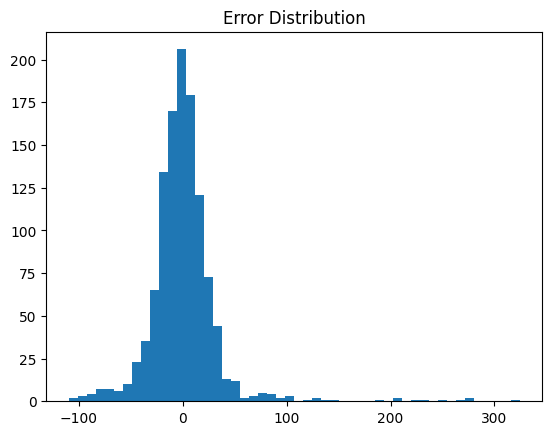

In [141]:
plt.hist(results['Error'], bins=50)
plt.title("Error Distribution")
plt.show()

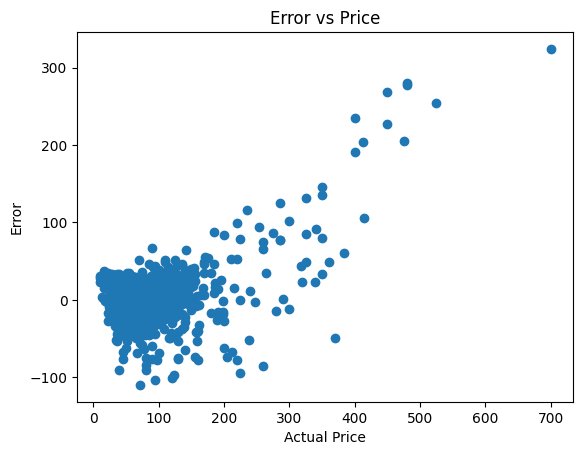

In [142]:
plt.scatter(results['Actual'], results['Error'])
plt.xlabel("Actual Price")
plt.ylabel("Error")
plt.title("Error vs Price")
plt.show()

In [143]:
# Model is not performing well on extreme values (low & high price properties) 
# Model is bias towards predicting mid-range properties more accurately 
# this happens because there are more mid-range properties in the dataset than extreme values, 
# so the model is learning more from mid-range properties and it is not able to generalize well on extreme values.

# High value properties are underpredicted and low value properties are overpredicted, 
# which is a common issue in regression models when there is an imbalance in the target variable distribution.
# Also, variance of error increases as price increases, indicating heteroscedasticity, 
# which can be addressed with techniques like log transformation or using models that can handle it better.

# Homoscedasticity means errors are equally spread across all values
# that is cheap house small error, mid house small error, expensive house small error
# same spread everywhere, but here we can see that as price increases error also increases, 
# which is heteroscedasticity which means cheap house small error, mid house small error, 
# expensive house large error, which can be a problem for linear regression as it assumes homoscedasticity
# so error variance increases with price, which can be a problem for linear regression

# Solution:
# 1. We can try log transformation on the target variable price to reduce the effect of extreme values 
# and to stabilize the variance of errors. this compresses the range of price and can help to reduce 
# the impact of outliers and heteroscedasticity and thus stabilize the variance of errors across different price ranges.
# 2. We can also try using models that can handle heteroscedasticity better

In [144]:
df.head()

,availability,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk,Carpet Area,Plot Area,...,Thigalarapalya,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,1,3.0,2.0,160.0,1670.0,3.0,556.666667,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,3.0,3.0,149.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3.0,2.0,150.0,1672.0,3.0,557.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,3.0,2.0,150.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,2.0,2.0,65.0,1425.0,3.0,475.000000,0.666667,False,False,...,False,False,False,False,False,False,False,False,False,False


In [145]:
# Apply log transform on price column
X = df.drop(columns=['price','bath','new_size', 'sqft_per_bhk'])
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [146]:
# Scaling numerical features, fit only on train and transform on both train and test to prevent data leakage
scaler = StandardScaler()

X_train[nums_cols_to_scale] = scaler.fit_transform(X_train[nums_cols_to_scale])
X_test[nums_cols_to_scale] = scaler.transform(X_test[nums_cols_to_scale])

In [147]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [148]:
y_pred_log = lr.predict(X_test)

In [149]:
# convert back to original scale
y_pred = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

In [150]:
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
r2 = r2_score(y_test_original, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 40.41456965821762
R2 Score: 0.6200806899009972


In [151]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2 = r2_score(y_test, y_pred_log)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.2740047343253672
R2 Score: 0.7685613816938373


In [152]:
# XG boost is the final model that we have selected

In [153]:
from sklearn.model_selection import GridSearchCV

In [154]:
X = df.drop(columns=['price'])
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [155]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [156]:
print("Best params:",grid.best_params_)
best_xgb = grid.best_estimator_

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [157]:
y_pred = best_xgb.predict(X_test)

In [158]:
# evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)

Tuned RMSE: 0.251119360985694
Tuned R2: 0.8056072383908277


In [159]:
y_pred_original = np.exp(y_pred)
y_test_original = np.exp(y_test)

rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2_original = r2_score(y_test_original, y_pred_original)

print("Original RMSE:", rmse_original)
print("Original R2:", r2_original)

Original RMSE: 34.39487036024151
Original R2: 0.7248289099467995


In [160]:
# lets test this xgb on one X_test row and get the predicted price in original scale
print(X_test[0:1])

     availability  bath  balcony  new_total_sqft  new_size  sqft_per_bhk  \
702             1   2.0      1.0          1400.0       2.0         700.0   

     bath_per_bhk  Carpet  Area  Plot  Area  Super built-up  Area  ...  \
702           1.0         False       False                  True  ...   

     Thigalarapalya  Tumkur Road  Uttarahalli  Varthur  Vijayanagar  \
702           False        False        False    False        False   

     Vittasandra  Whitefield  Yelahanka  Yelahanka New Town  Yeshwanthpur  
702        False       False      False               False         False  

[1 rows x 108 columns]


In [161]:
np.exp(5.1627216)

np.float64(174.63910720039368)

In [162]:
# Acceptable Error Tracking 
percentage_error = np.abs((y_test_original - y_pred_original) / y_test_original) * 100
print(percentage_error.describe())

count    1148.000000
mean       19.045075
std        17.403567
min         0.007427
25%         6.785173
50%        14.715243
75%        25.561524
max       161.459007
Name: price, dtype: float64


In [163]:
# Add this error percentage to the results dataframe for error analysis
results = pd.DataFrame({
    'Actual': y_test_original,
    'Predicted': y_pred_original
})
results['Percentage_Error'] = percentage_error
results.sort_values(by='Percentage_Error', ascending=False)

,Actual,Predicted,Percentage_Error
1676,40.0,104.583603,161.459007
3730,45.0,105.714516,134.921146
3942,35.0,75.734787,116.385106
4178,51.0,104.897087,105.680563
2823,50.0,100.514786,101.029572
...,...,...,...
4917,38.0,38.024902,0.065532
4047,52.0,52.024757,0.047610
1850,48.0,47.979691,0.042311
4721,350.0,350.089752,0.025643


In [164]:
# check values where percentage error is greater than 10%, 20%, 30%
print(results[results['Percentage_Error'] > 10].shape)
print(results[results['Percentage_Error'] > 20].shape)
print(results[results['Percentage_Error'] > 30].shape)

(757, 3)
(407, 3)
(227, 3)


In [165]:
# lets reverse this 10%, 20%, 30%
# lets calculate the exact number of values in this percentage
print(results[results['Percentage_Error'] <= 10].shape)
print(results[results['Percentage_Error'] <= 20].shape)
print(results[results['Percentage_Error'] <= 30].shape)

# lets check the percentage also for this three above
print(results[results['Percentage_Error'] <= 10].shape[0] / results.shape[0] * 100)
print(results[results['Percentage_Error'] <= 20].shape[0] / results.shape[0] * 100)
print(results[results['Percentage_Error'] <= 30].shape[0] / results.shape[0] * 100)

# this tell us that around 36% of the predictions are within 10% error, 
# around 65% of the predictions are within 20% error, and around 80% of the predictions are within 30% error

(391, 3)
(741, 3)
(921, 3)
34.05923344947735
64.54703832752612
80.22648083623693


In [166]:
# pd.qcut sort the Actual column first and the split that it into 3 equal groups
# that is low price segment, mid price segment and high price segment

results["price_segment"] = pd.qcut(
    results["Actual"], 
    q=3, 
    labels=["low", "mid", "high"]
)

print(results.groupby("price_segment")["Percentage_Error"].mean())

# this tells us that:
# 1. mid range properties gives us the best results - 16%
# meaning on average mid range houses have lowest prediction error
# 2. low range properties performed worse - 21%
# 3. high range properties also performed worse - 19%

# From my understanding this is happening is because:
# 1. Mid range properties are more common in the dataset, so the model has 
# more data to learn from and thus performs better on them.
# Therefore, the model is biased towards predicting mid-range properties more accurately
# As data is imbalanced with more mid-range properties,and model predicts those values better on average

# we can fix this by using techniques like (this are hit & trial methods, we have to try and see which one works best for our dataset):
# 1. Data augmentation for low and high price segments to create more training examples for those 
# segments, which can help the model learn better and improve its performance on those segments.
# 2. Using different evaluation metrics that give more weight to errors in low and high price segments,
# such as weighted mean absolute error or custom loss functions that penalize errors in those segments more 
# heavily, which can encourage the model to focus on improving its predictions for those segments.
# 3. Using ensemble methods that combine predictions from multiple models, where some models are specifically 
# trained to perform well on low and high price segments, which can help improve overall performance across all segments.
# 4. Using techniques like SMOTE (Synthetic Minority Over-sampling Technique) to balance the dataset by generating 
# synthetic samples for the underrepresented low and high price segments, which can help the model learn better and improve its performance on those segments.
# 5. Using stratified sampling during train-test split to ensure that the distribution of low, mid, and high price segments is maintained in both the 
# training and testing sets, which can help the model learn better and improve its performance across all segments.

price_segment
low     20.991755
mid     16.637804
high    19.226550
Name: Percentage_Error, dtype: float64


C:\Users\munja\AppData\Local\Temp\ipykernel_3904\2079101857.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(results.groupby("price_segment")["Percentage_Error"].mean())


In [167]:
# To Conclude:
# The model performs best on mid-range properties due to higher data density in that region. 
# Errors are higher in low and high price segments because of data imbalance and increased variability, 
# making those regions harder to model accurately.

In [168]:
worst_cases = results.sort_values(by="Percentage_Error", ascending=False).head(20)
print(worst_cases)

      Actual   Predicted  Percentage_Error price_segment
1676   40.00  104.583603        161.459007           low
3730   45.00  105.714516        134.921146           low
3942   35.00   75.734787        116.385106           low
4178   51.00  104.897087        105.680563           low
2823   50.00  100.514786        101.029572           low
873    80.00  160.190323        100.237904           mid
184    77.00  150.260315         95.143266           mid
2861   36.00   70.035416         94.542821           low
3289   18.50   35.855473         93.813365           low
1414   95.00  178.717148         88.123314          high
4357   20.50   37.894680         84.852098           low
6274   41.00   75.788292         84.849493           low
4218   75.00  136.635452         82.180603           mid
927    33.00   59.856750         81.384092           low
5947   71.00  126.974831         78.837790           mid
463    36.00   61.366825         70.463403           low
3068   70.00  119.157768       

In [169]:
X_test_reset = X_test.reset_index(drop=True)
worst_cases_reset = worst_cases.reset_index(drop=True)

debug_df = pd.concat([worst_cases_reset, X_test_reset], axis=1)
debug_df.head()

,Actual,Predicted,Percentage_Error,price_segment,availability,bath,balcony,new_total_sqft,new_size,sqft_per_bhk,...,Thigalarapalya,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,40.0,104.583603,161.459007,low,1,2.0,1.0,1400.0,2.0,700.000000,...,False,False,False,False,False,False,False,False,False,False
1,45.0,105.714516,134.921146,low,1,3.0,2.0,1680.0,3.0,560.000000,...,False,False,False,False,False,False,False,False,False,False
2,35.0,75.734787,116.385106,low,1,3.0,2.0,1760.0,3.0,586.666667,...,False,False,False,False,False,False,False,False,False,False
3,51.0,104.897087,105.680563,low,0,3.0,2.0,1200.0,3.0,400.000000,...,False,False,False,False,False,False,True,False,False,False
4,50.0,100.514786,101.029572,low,1,2.0,3.0,1065.0,2.0,532.500000,...,False,False,False,False,False,False,False,False,False,False


In [170]:
print(debug_df[['Actual', 'Predicted', 'Percentage_Error', 'price_segment','new_total_sqft']].head(20))

    Actual   Predicted  Percentage_Error price_segment  new_total_sqft
0    40.00  104.583603        161.459007           low          1400.0
1    45.00  105.714516        134.921146           low          1680.0
2    35.00   75.734787        116.385106           low          1760.0
3    51.00  104.897087        105.680563           low          1200.0
4    50.00  100.514786        101.029572           low          1065.0
5    80.00  160.190323        100.237904           mid           660.0
6    77.00  150.260315         95.143266           mid          1070.0
7    36.00   70.035416         94.542821           low          1660.0
8    18.50   35.855473         93.813365           low          1125.0
9    95.00  178.717148         88.123314          high          1275.0
10   20.50   37.894680         84.852098           low          1128.0
11   41.00   75.788292         84.849493           low          1346.0
12   75.00  136.635452         82.180603           mid          1296.0
13   3

In [171]:
print(debug_df[['Actual', 'Predicted', "new_size", "new_total_sqft", "sqft_per_bhk"]].head(20))

    Actual   Predicted  new_size  new_total_sqft  sqft_per_bhk
0    40.00  104.583603       2.0          1400.0    700.000000
1    45.00  105.714516       3.0          1680.0    560.000000
2    35.00   75.734787       3.0          1760.0    586.666667
3    51.00  104.897087       3.0          1200.0    400.000000
4    50.00  100.514786       2.0          1065.0    532.500000
5    80.00  160.190323       1.0           660.0    660.000000
6    77.00  150.260315       2.0          1070.0    535.000000
7    36.00   70.035416       3.0          1660.0    553.333333
8    18.50   35.855473       2.0          1125.0    562.500000
9    95.00  178.717148       3.0          1275.0    425.000000
10   20.50   37.894680       2.0          1128.0    564.000000
11   41.00   75.788292       3.0          1346.0    448.666667
12   75.00  136.635452       2.0          1296.0    648.000000
13   33.00   59.856750       3.0          1640.0    546.666667
14   71.00  126.974831       4.0          1900.0    475

In [172]:
# Below points are of Root Cause Analysis:
# RCA is not just identifying that errors exist, but explaining why they happen based on data + model behavior
# Without RCA we say that: Model has 30% error, r2 is 0.83, rmse is high, some predictions are wrong
# this are symptoms of the problem but not the root cause, RCA is to find the underlying reason for these symptoms,
# With RCA we say that:
# 1.Errors happen because large sqft but low price breaks learned pattern
# 2.Model is biased towards predicting higher prices as it maybe due to right skewed distribution(tackled using np.log(price))
# 3.Model overpredicts because it learned sqft → price relationship
# 4.Low-price % error is inflated due to denominator effect
# 5.1 BHK with 1500 sqft is unusual and model overpredicts due to learned patterns
# These are called causal explanations, they explain why the model is making certain errors based on the data and 
# the patterns it has learned during training.


# In the worst performing cases:
# 1. The pattern is of overestimation only one case of understimation is there that is 240 to 54 prediction
#  Model is biased towards predicting higher prices as it maybe due to right skewed distribution

# 2. These worst performing houses are large in size but low in price, which is unusual 
# because what model has learned from the training data large sqft means high price
# but when during testing model sees this data large sqft but low price, it gets confused and 
# it overestimates the price significantly,because it has never seen such data during training, 
# so it is not able to generalize and this breaks learned pattern
# Model says: this should be expensive because it has large sqft, but in reality it is not expensive, so it overestimates the price significantly
# therfore predicts high price, huge error

# 3. 1 BHK → 1500 sqft model expects around 500-700 sqft/bhk but here it is 1500 sqft/bhk which is high
#  Model has learned that 1 BHK means around 500-700 sqft, but here it is 1500 sqft which is unusual,
# and the model predict or assumes that it should be expensive because it has large sqft, but in reality it is not expensive, so it overestimates the price significantly

# 4.Low-price sensivity:
# Actual:14 Predicted:26 in reality it is no that overestimation
# but when we look at the percentage error = abs(Actual - Predicted) / (Actual) * 100
# percentage error = (14-26)/(14) * 100 = 85.7% which is very high percentage error
# Actual:200 Predicted:212 percentage error = (200-212)/(200) * 100 = 6% which is low percentage error
# so even though the absolute error is 12 in both cases, the percentage error is very high in the first case 
# because the actual price is low, which makes the model look like it is performing worse than it actually is in 
# low price segment. This is a common issue when evaluating model performance on imbalanced datasets with a wide 
# range of target variable values. Therefore, it is important to consider both absolute and percentage errors when 
# analyzing model performance, especially in cases where the target variable has a wide range of values. 

In [173]:
# Trade-off
# After performing root cause analysis, I applied targeted data consistency improvements. 
# This led to a slight drop in R², but significantly reduced extreme 
# prediction errors and improved model robustness. I prioritized stability over marginal accuracy gains

In [174]:
# Low-price segment shows higher percentage error due to denominator sensitivity and higher variance
# During error analysis, I observed that the model was making a few extremely large errors (150–180%) due to inconsistent feature patterns. I decided to prioritize model stability over marginal accuracy improvements.
# I applied targeted data consistency filtering to remove unrealistic feature combinations, which slightly reduced R² but significantly reduced extreme prediction errors.
# The trade-off I made was sacrificing a small amount of overall accuracy to improve reliability and reduce high-impact errors, which is more important in real-world decision-making.

# Step - 1:
# Model had high R² but was producing extreme errors (150%+) in some cases
# Step - 2:
# I applied data consistency filtering based on root cause analysis to remove unrealistic feature combinations
# Step - 3:
# This reduced R² slightly, but significantly improved prediction stability and reduced high-impact errors

# High overall accuracy doesn’t guarantee reliable predictions. 
# In our case, the model had good R² but produced a few extreme errors, 
# which can be very harmful in real-world decisions. For example, overpricing 
# a property by a large margin can prevent it from selling, while underpricing can cause financial loss.
# So I prioritized reducing high-impact errors to improve reliability and user trust, 
# even if it meant a small drop in overall accuracy.

In [175]:
# Lets check model biasness by looking at the price segments in the raw dataset:
df_analysis = df.copy()
df_analysis.head()

,availability,bath,balcony,price,new_total_sqft,new_size,sqft_per_bhk,bath_per_bhk,Carpet Area,Plot Area,...,Thigalarapalya,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,1,3.0,2.0,160.0,1670.0,3.0,556.666667,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,3.0,3.0,149.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3.0,2.0,150.0,1672.0,3.0,557.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,3.0,2.0,150.0,1750.0,3.0,583.333333,1.000000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,2.0,2.0,65.0,1425.0,3.0,475.000000,0.666667,False,False,...,False,False,False,False,False,False,False,False,False,False


In [176]:
df_analysis['price_segment'] = pd.qcut(
    df_analysis['price'], 
    q=3, 
    labels=["low", "mid", "high"]
)

In [177]:
# Count Distribution of price segments
print(df_analysis['price_segment'].value_counts())
print(df_analysis['price_segment'].value_counts(normalize=True) * 100)

price_segment
low     1944
mid     1919
high    1873
Name: count, dtype: int64
price_segment
low     33.891213
mid     33.455370
high    32.653417
Name: proportion, dtype: float64


In [178]:
# The model shows performance imbalance across segments, not because of data imbalance, 
# but due to differences in feature complexity and variability.

# How to fix it?
# our RCA shows that: same sqft + bhk → different prices (esp. high end)
# so we can fix this by creating new features that can capture the complexity of high-end properties better,
# such as:
# sqft * location_median_price_per_sqft, sqft_per_bhk * location
# Give the model more information to separate similar-looking houses
# Second thing:
# Train separate models for each price segment, so that each model can learn the specific patterns and 
# relationships within its segment, which can help improve performance across all segments.
# pseudo-logic:
# if predicted_segment == "low":
#     use model_low
# elif "mid":
#     use model_mid
# else:
#     use model_high
# Third Thing:
# Collect more real data:
# 1. more high-end properties to learn better patterns for that segment
# 2. more low-end properties to learn better patterns for that segment